In [133]:
import numpy as np
import matplotlib.pyplot as plt
from time import perf_counter

Definimos o número de pontos a serem amostrados e as funções

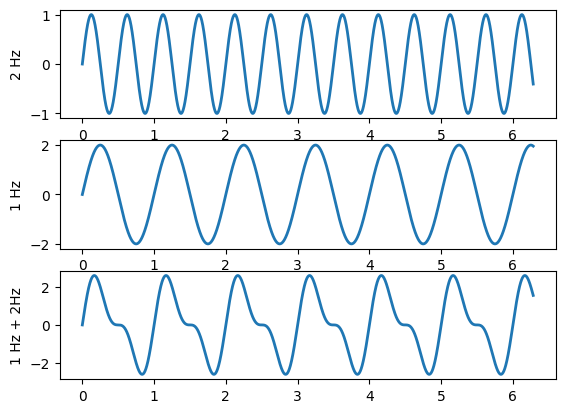

In [134]:
n = 6000 # number of points
t_inicial = 0
t_final = 2*np.pi

sr = n / (t_final - t_inicial) # sampling rate (Hz)

x = np.linspace(t_inicial, t_final, n)

oneHzinRad = 2*np.pi

f = 2* np.sin(oneHzinRad * x) # 1hz and amplitude of 2
f_2 = np.sin(2 * oneHzinRad*x) # 2Hz and amplitude of 1

f_3 = f + f_2

fig, ax_mine = plt.subplots(3, 1)

ax_mine[0].plot(x,  f_2, linewidth=2.0)
ax_mine[0].set_ylabel("2 Hz")

ax_mine[1].plot(x,  f, linewidth=2.0)
ax_mine[1].set_ylabel("1 Hz")

ax_mine[2].plot(x,  f_3, linewidth=2.0)
ax_mine[2].set_ylabel("1 Hz + 2Hz")

plt.show()

## Discrete Fourier Transform

The Discrete Fourier Transform takes a discrete function in the time 
domain and transforms it to the frequency domain via the following sum:

$$X[k] = \sum_{i=0}^{N-1} x[i] \cdot e^{-j 2\pi k i / N}$$

Letting $w_N = e^{-j 2\pi / N}$, this becomes:

$$X[k] = \sum_{i=0}^{N-1} x[i] \, w_N^{ki}$$

Expanding term by term:

$$X[0] = x[0] + x[1] + x[2] + \ldots + x[N-1]$$
$$X[1] = x[0] + x[1]w_N + x[2]w_N^2 + \ldots + x[N-1]w_N^{N-1}$$
$$X[2] = x[0] + x[1]w_N^2 + x[2]w_N^4 + \ldots + x[N-1]w_N^{2(N-1)}$$
$$\vdots$$
$$X[N-1] = x[0] + x[1]w_N^{N-1} + \ldots + x[N-1]w_N^{(N-1)^2}$$

This can be written compactly as the matrix equation $X = Wx$, where 
$X \in \mathbb{C}^{N\times 1}$, $x \in \mathbb{R}^{N\times 1}$, and 
$W \in \mathbb{C}^{N\times N}$ is the DFT matrix:

$$W = \begin{bmatrix}
    1 & 1 & 1 & \cdots & 1 \\
    1 & w_N & w_N^2 & \cdots & w_N^{N-1} \\
    1 & w_N^2 & w_N^4 & \cdots & w_N^{2(N-1)} \\
    \vdots & \vdots & \vdots & \ddots & \vdots \\
    1 & w_N^{N-1} & w_N^{2(N-1)} & \cdots & w_N^{(N-1)^2}
\end{bmatrix}$$

### Important notes

1. Given a signal with $N$ samples over a time interval $\Delta t$, the 
sampling rate is $sr = N / \Delta t$. By the Nyquist theorem, the highest 
representable frequency is $f_{max} = sr / 2$, so the one-sided spectrum 
spans from $0$ to $f_{max}$.

2. The DFT scales all amplitudes by $N$. To recover the true physical 
amplitude of the signal, divide by $N$. In the one-sided spectrum, each 
bin (except DC) also receives a factor of 2 to compensate for the 
discarded negative frequencies, making the effective normalization $N/2$.

3. Both our DFT implementation and NumPy's `np.fft.fft()` return the full 
spectrum from $0$ to $sr$, mirrored at $f_{max}$. The negative-frequency 
half is redundant for real-valued signals and is discarded when computing 
the one-sided spectrum.

In [135]:
def naiveDFT(x):
    N = len(x)

    n = np.arange(N)
    k = n.reshape((N, 1))

    W = np.exp(-2j * np.pi * k * n / N)
    X = W @ x

    return X

def getFrequencyAxis(X, sr):
    N = len(X)
    n = np.arange(N)
    T = N/sr
    freq = n/T
    return freq

954.9296585513721


Text(0.5, 0, 'Frequency Hz NumPy')

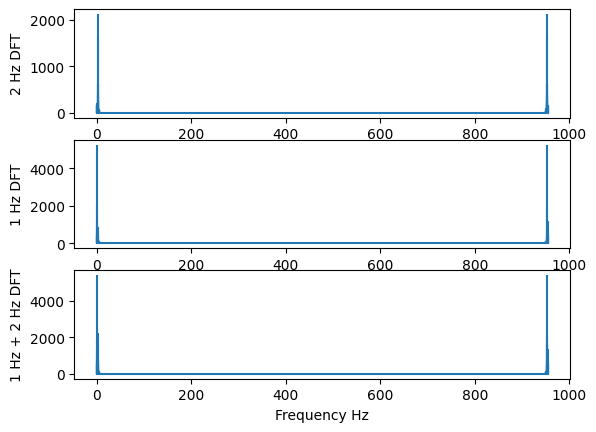

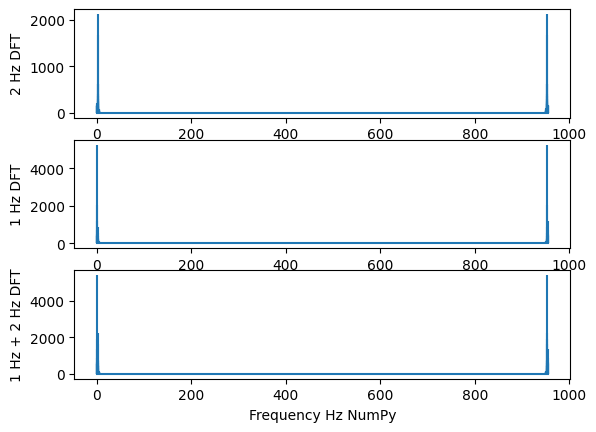

In [136]:
F = naiveDFT(f)
F_2 = naiveDFT(f_2)
F_3 = naiveDFT(f_3)

npF = np.fft.fft(f)
npF_2 = np.fft.fft(f_2)
npF_3 = np.fft.fft(f_3)

freq = getFrequencyAxis(F, sr)

print(sr)

fig_mine, ax_mine = plt.subplots(3, 1)
fig_numpy, ax_numpy = plt.subplots(3, 1)

ax_mine[0].stem(freq, abs(F_2), markerfmt='', basefmt='', label='mine')
ax_numpy[0].stem(freq, abs(npF_2), markerfmt='', basefmt='', label='np')
ax_mine[0].set_ylabel("2 Hz DFT")
ax_numpy[0].set_ylabel("2 Hz DFT")

ax_mine[1].stem(freq, abs(F), markerfmt='', basefmt='', label='mine')
ax_numpy[1].stem(freq, abs(npF), markerfmt='', basefmt='', label='np')
ax_mine[1].set_ylabel("1 Hz DFT")
ax_numpy[1].set_ylabel("1 Hz DFT")

ax_mine[2].stem(freq, abs(F_3), markerfmt='', basefmt='', label='mine')
ax_numpy[2].stem(freq, abs(npF_3), markerfmt='', basefmt='', label='np')
ax_mine[2].set_ylabel("1 Hz + 2 Hz DFT")
ax_numpy[2].set_ylabel("1 Hz + 2 Hz DFT")

ax_mine[2].set_xlabel('Frequency Hz')
ax_numpy[2].set_xlabel('Frequency Hz NumPy')

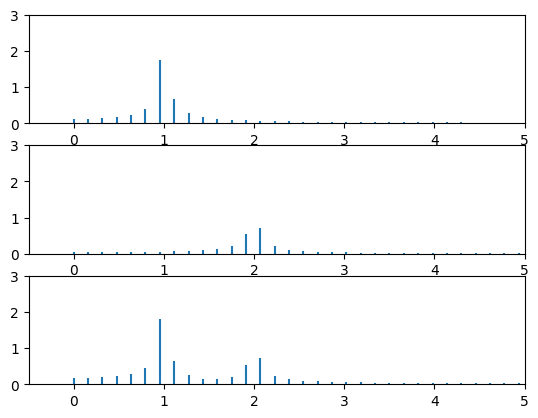

In [137]:
# 5. Criando o eixo de frequências unilateral
frequencias = np.fft.fftfreq(n, 1/sr)[:n//2]

# Equivalente a fazer isso:
# delta_f = 1 / (t_final - t_inicial)
# frequencias = np.arange(n//2) * delta_f

npF_unilateral = np.abs(npF[: n//2]) / (n/2)
npF_2_unilateral = np.abs(npF_2[: n//2]) / (n/2)
npF_3_unilateral = np.abs(npF_3[: n//2]) / (n/2)


# 6. SHIFT: Rotacionar os vetores para colocar a frequência 0 no centro
frequencias_shift = np.fft.fftshift(frequencias)

fig, axis = plt.subplots(3, 1)

axis[0].stem(frequencias, npF_unilateral, basefmt=" ", markerfmt=' ')
axis[1].stem(frequencias, npF_2_unilateral, basefmt=" ", markerfmt=' ')
axis[2].stem(frequencias, npF_3_unilateral, basefmt=" ", markerfmt=' ')

for ax in axis:
    ax.set_xlim(-0.5, 5)
    ax.set_ylim(0, 3)

plt.show()

### Performance of naive DFT algorithm is O(n²)

In [138]:
def gen_sig(n):
    '''
      function to generate
      a simple 1D signal with
      different sampling rate (n)
    '''
    ts = 1.0/n
    t = np.arange(0,1,ts)

    freq = 1.
    x = 3*np.sin(2*np.pi*freq*t)
    return x

In [139]:
n_test = 1

%timeit naiveDFT(gen_sig(n_test))

20.1 μs ± 969 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [140]:
n_test = 2000

%timeit naiveDFT(gen_sig(n_test))

283 ms ± 21.3 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [141]:
n = 4000

%timeit naiveDFT(gen_sig(n))

760 ms ± 79.4 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [142]:
n_test = 8000

%timeit naiveDFT(gen_sig(n_test))

3.53 s ± 426 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


## Fast Fourier Transform FFT